# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Tran Hoang Binh An"  # TODO: Họ và tên
STUDENT_ID = "2520001"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Tran Hoang Binh An (2520001)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd '/content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw'

/content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:",  DATA_PATH.resolve())

Data path: /content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [5]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [6]:
# TODO N1
# shifted_logits = ...
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
print(shifted_logits)

# exp_logits = ...
exp_logits = np.exp(shifted_logits)
print(np.round(exp_logits), 4)

# class_probabilities = ...
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
print(np.round(class_probabilities, 4))

# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis=1)
print(np.round(predicted_classes, 4))

# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis=1)
print(np.round(confidence_scores, 4))

[[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 1. 1.]] 4
[[0.659  0.2424 0.0986]
 [0.2447 0.6652 0.09  ]
 [0.0066 0.0179 0.9756]
 [0.3333 0.3333 0.3333]]
[0 1 2 0]
[0.659  0.6652 0.9756 0.3333]


In [7]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [8]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [9]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = np.mean(X_train, axis=0)
print(np.round(train_feature_mean, 4))

# train_feature_std = ...
train_feature_std = np.std(X_train, axis=0)
print(np.round(train_feature_std, 4))

# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
print(np.round(X_train_scaled, 4))

# X_val_scaled = ...
X_val_scaled = (X_val - train_feature_mean) / train_feature_std
print(np.round(X_val_scaled, 4))

[172.5     69.1667   1.65    28.1667]
[ 7.4777 13.0437  0.7911  7.6467]
[[-0.3343 -0.3194 -0.5688 -0.8064]
 [ 1.003   0.8305  0.9481  0.8936]
 [-1.6716 -1.4694 -1.0745 -1.1988]
 [ 0.3343  0.0639 -0.1896 -0.0218]
 [-0.6018 -0.7028 -0.8216 -0.5449]
 [ 1.2704  1.5972  1.7065  1.6783]]
[[-0.0669 -0.0894 -0.316  -0.2833]
 [ 2.3403  1.9805  2.2121  2.2014]]


In [10]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [11]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [12]:
# TODO N3
# correct_mask = ...
correct_mask = true_labels == predicted_classes
print(f'Correct Mask: ', correct_mask)

# high_confidence_mask = ...
high_confidence_mask = confidence_scores >= confidence_threshold
print(f'Confident Mask: ', high_confidence_mask)

# review_mask = ...
review_mask = np.logical_not(np.logical_and(correct_mask, high_confidence_mask))
print(f'Review Mask: ', review_mask)

# review_indices = ...
review_indices = np.where(review_mask)[0]
print(f'Review Indices: ', review_indices)

Correct Mask:  [ True False  True False]
Confident Mask:  [False False  True False]
Review Mask:  [ True  True False  True]
Review Indices:  [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [13]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [14]:
image_batch_uint8

array([[[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[24, 25, 26],
         [27, 28, 29],
         [30, 31, 32],
         [33, 34, 35]],

        [[36, 37, 38],
         [39, 40, 41],
         [42, 43, 44],
         [45, 46, 47]]],


       [[[48, 49, 50],
         [51, 52, 53],
         [54, 55, 56],
         [57, 58, 59]],

        [[60, 61, 62],
         [63, 64, 65],
         [66, 67, 68],
         [69, 70, 71]],

        [[72, 73, 74],
         [75, 76, 77],
         [78, 79, 80],
         [81, 82, 83]],

        [[84, 85, 86],
         [87, 88, 89],
         [90, 91, 92],
         [93, 94, 95]]]], dtype=uint8)

In [15]:
# TODO N4
# normalized_batch = ...
print('Normalized Batch')
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
print(np.round(normalized_batch, 4))

# augmented_batch = ...
print('\nAugmented Batch')
augmented_batch = np.flip(normalized_batch, axis=2)
print(np.round(augmented_batch, 4))

# augmented_batch[0, 0, 0, 0] = ...
print('\nSet augmented_batch[0, 0, 0, 0] = 1.0')
augmented_batch[augmented_batch == augmented_batch[0, 0, 0, 0]] = 1.0
print(np.round(augmented_batch, 4))

Normalized Batch
[[[[0.     0.0039 0.0078]
   [0.0118 0.0157 0.0196]
   [0.0235 0.0275 0.0314]
   [0.0353 0.0392 0.0431]]

  [[0.0471 0.051  0.0549]
   [0.0588 0.0627 0.0667]
   [0.0706 0.0745 0.0784]
   [0.0824 0.0863 0.0902]]

  [[0.0941 0.098  0.102 ]
   [0.1059 0.1098 0.1137]
   [0.1176 0.1216 0.1255]
   [0.1294 0.1333 0.1373]]

  [[0.1412 0.1451 0.149 ]
   [0.1529 0.1569 0.1608]
   [0.1647 0.1686 0.1725]
   [0.1765 0.1804 0.1843]]]


 [[[0.1882 0.1922 0.1961]
   [0.2    0.2039 0.2078]
   [0.2118 0.2157 0.2196]
   [0.2235 0.2275 0.2314]]

  [[0.2353 0.2392 0.2431]
   [0.2471 0.251  0.2549]
   [0.2588 0.2627 0.2667]
   [0.2706 0.2745 0.2784]]

  [[0.2824 0.2863 0.2902]
   [0.2941 0.298  0.302 ]
   [0.3059 0.3098 0.3137]
   [0.3176 0.3216 0.3255]]

  [[0.3294 0.3333 0.3373]
   [0.3412 0.3451 0.349 ]
   [0.3529 0.3569 0.3608]
   [0.3647 0.3686 0.3725]]]]

Augmented Batch
[[[[0.0353 0.0392 0.0431]
   [0.0235 0.0275 0.0314]
   [0.0118 0.0157 0.0196]
   [0.     0.0039 0.0078]]

  [[0.082

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**
1. Tupple
2. ?
3. symboling có ý nghĩa gì? Mức đánh giá rủi ro bảo hiểm
<!-- Viết câu trả lời tại đây. -->

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [16]:
# TODO D1
# raw_df = ...
raw_df = pd.read_csv(DATA_PATH, na_values='?')
print(raw_df)

# raw_shape = ...
raw_shape = raw_df.shape
print(raw_shape)

# raw_missing_marker_count = ...
raw_missing_marker_count = raw_df.isna().sum().sum()
print(raw_missing_marker_count)

     symboling  normalized_losses         make fuel_type aspiration num_doors  \
0            3                NaN  alfa-romero       gas        std       two   
1            3                NaN  alfa-romero       gas        std       two   
2            1                NaN  alfa-romero       gas        std       two   
3            2              164.0         audi       gas        std      four   
4            2              164.0         audi       gas        std      four   
..         ...                ...          ...       ...        ...       ...   
200         -1               95.0        volvo       gas        std      four   
201         -1               95.0        volvo       gas      turbo      four   
202         -1               95.0        volvo       gas        std      four   
203         -1               95.0        volvo    diesel      turbo      four   
204         -1               95.0        volvo       gas      turbo      four   

      body_style drive_whee

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [17]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [18]:
# TODO D2
# df_clean = ...
df_clean = raw_df.copy()
# for column in NUMERIC_COLUMNS:
#     ...
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')
print(df_clean)

# missing_by_column = ...
missing_by_column = df_clean.isna().sum()
print(missing_by_column)

     symboling  normalized_losses         make fuel_type aspiration num_doors  \
0            3                NaN  alfa-romero       gas        std       two   
1            3                NaN  alfa-romero       gas        std       two   
2            1                NaN  alfa-romero       gas        std       two   
3            2              164.0         audi       gas        std      four   
4            2              164.0         audi       gas        std      four   
..         ...                ...          ...       ...        ...       ...   
200         -1               95.0        volvo       gas        std      four   
201         -1               95.0        volvo       gas      turbo      four   
202         -1               95.0        volvo       gas        std      four   
203         -1               95.0        volvo    diesel      turbo      four   
204         -1               95.0        volvo       gas      turbo      four   

      body_style drive_whee

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
1. Vì giá trị của mỗi cột là khác nhau về phân phối dữ liệu
2. Fill vì missing value rất ít
3. Không biểu diễn được sự phụ thuộc của biến normalized_losses đến các biên khác

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [19]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [20]:
from re import X
# TODO D3
# analysis_df = ...
analysis_df = df_clean[AUTO_FEATURES].dropna(subset=AUTO_FEATURES)
print(analysis_df)

# X_auto = ...
X_auto = analysis_df[AUTO_FEATURES].to_numpy().astype(np.float64)
print(X_auto)

# auto_feature_mean = ...
auto_feature_mean = X_auto.mean(axis=0)
print(auto_feature_mean)

# auto_feature_std = ...
auto_feature_std = X_auto.std(axis=0)
print(auto_feature_std)

# X_auto_scaled = ...
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std
print(X_auto_scaled)

     curb_weight  engine_size  horsepower  city_mpg  highway_mpg    price
0           2548          130       111.0        21           27  13495.0
1           2548          130       111.0        21           27  16500.0
2           2823          152       154.0        19           26  16500.0
3           2337          109       102.0        24           30  13950.0
4           2824          136       115.0        18           22  17450.0
..           ...          ...         ...       ...          ...      ...
200         2952          141       114.0        23           28  16845.0
201         3049          141       160.0        19           25  19045.0
202         3012          173       134.0        18           23  21485.0
203         3217          145       106.0        26           27  22470.0
204         3062          141       114.0        19           25  22625.0

[199 rows x 6 columns]
[[2.5480e+03 1.3000e+02 1.1100e+02 2.1000e+01 2.7000e+01 1.3495e+04]
 [2.5480e+03 1.3000

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [21]:
# TODO D4
# price_index = ...
price_index = AUTO_FEATURES.index('price')
print(price_index)

# price_z = ...
price_z = X_auto_scaled[:, price_index]
print(price_z)

# price_outlier_mask = ...
price_outlier_mask = np.abs(price_z) > 2
print(price_outlier_mask)

# price_outliers = ...
price_outliers = price_z[price_outlier_mask]
print(price_outliers)

5
[ 0.03160942  0.40918671  0.40918671  0.08878002  0.52855391  0.25212461
  0.56122283  0.71325894  1.33585312  0.40039123  0.46258783  0.97084079
  0.9878035   1.4225514   2.20095117  3.52718357  2.96992723 -1.01681153
 -0.87306829 -0.83788638 -0.96391301 -0.86276502 -0.66423852 -0.88136117
 -0.82318537 -0.70796461 -0.58872306 -0.54311223 -0.03511056 -0.84994875
 -0.80270447 -0.9856504  -0.84366626 -0.76827646 -0.74741861 -0.74741861
 -0.6720288  -0.52124918 -0.5526616  -0.37046956 -0.03749791 -0.36418708
 -0.81149995 -0.27585535  2.3881692   2.80281315  2.85935551 -1.01128294
 -0.89819823 -0.81024345 -0.82280842 -0.73485364 -0.28879727 -0.17571256
  0.05045687  0.30175623 -0.5526616  -0.59663899 -0.33277466 -0.37675205
 -0.30764472 -0.25110237  0.63284315  0.64088473  1.54656763  1.88531917
  1.8762724   2.30649691  2.63117569  2.74074221  3.48257793  4.04046252
  0.40956366 -0.9869069  -0.88638716 -0.82607531 -0.69791263 -0.41268786
 -0.59613639 -0.07720321  0.20425208  0.1565052  

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [25]:
# TODO D5
# engine_price_corr = ...
engine_price_corr = np.corrcoef(X_auto_scaled[:, 1], X_auto_scaled[:, -1])[0, 1]
print(engine_price_corr)

# price_by_body_style = ...
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()
print(price_by_body_style)

0.8738869517981525
body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

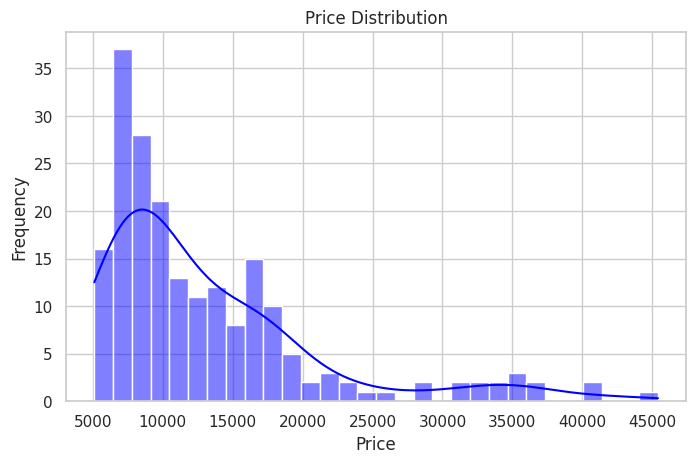

In [48]:
# TODO M2.1: histogram/KDE của price

sns.histplot(
    data=df_clean['price'],
    bins=30,
    kde=True,
    color='blue',
    alpha=0.5,
)

plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Phân phối lệch phải.

Giá nhà chia theo từng nhóm khách hàng.

Xuất hiện outlier ở phần đuôi phân phối


## M2.2 Dataset có cân bằng theo body style không?

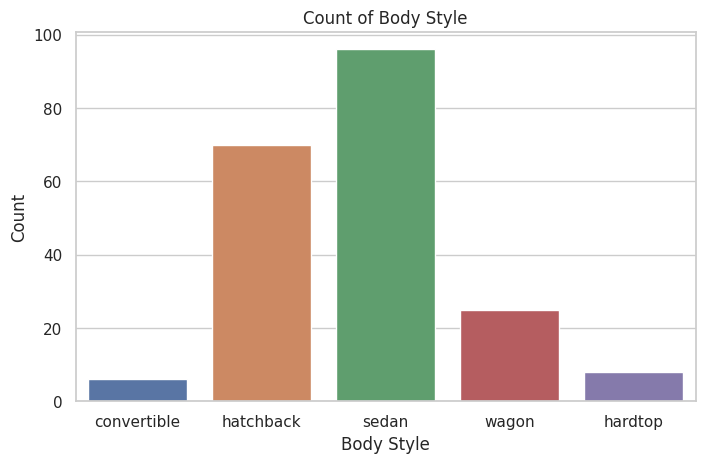

In [41]:
# TODO M2.2: countplot của body_style

sns.countplot(
    data=df_clean,
    x='body_style',
    hue='body_style',
)

plt.xlabel('Body Style')
plt.ylabel('Count')
plt.title('Count of Body Style')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Tập trung chủ yếu ở hatchback và sedan.

## M2.3 Price khác nhau theo body style ra sao?

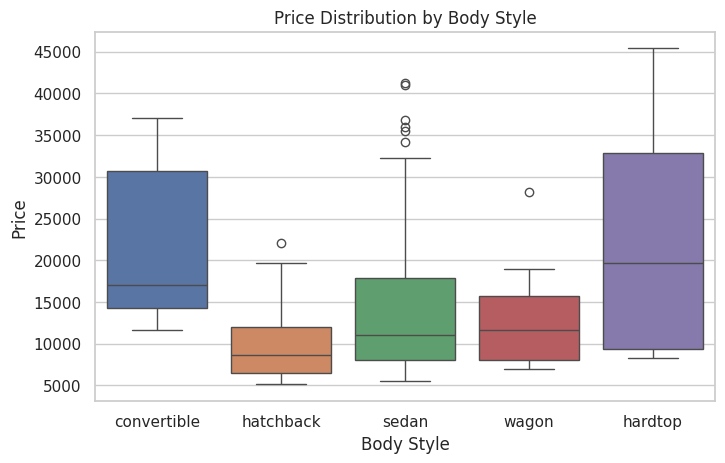

In [40]:
# TODO M2.3: boxplot price theo body_style

sns.boxplot(
    data=df_clean,
    x='body_style',
    y='price',
    hue='body_style',
)

plt.xlabel('Body Style')
plt.ylabel('Price')
plt.title('Price Distribution by Body Style')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Sedan có nhiều outlier cho phân khúc cao
Conver

hartop, convertible có giá trùng bình cao, khoảng giả rộng

hatchback có phân khúc giá hẹp.

## M2.4 Engine size liên quan thế nào tới price?

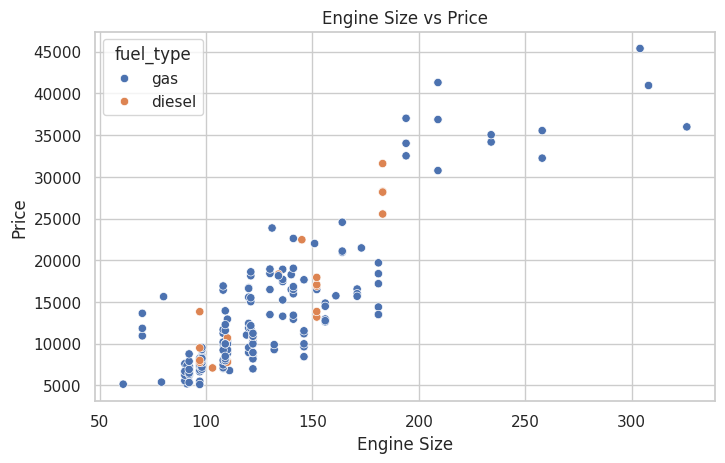

In [53]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type

sns.scatterplot(
    data=df_clean,
    x='engine_size',
    y='price',
    hue='fuel_type',
)

plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title('Engine Size vs Price')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Engine Size và Price tuyến tính với nhau

Động cơ Diesel thường có động cơ lớn hơn gas => động cơ có ảnh hưởng giá

Phân khúc giá cao nhất chủ yếu là Gas


## M2.5 Các feature numeric tương quan ra sao?

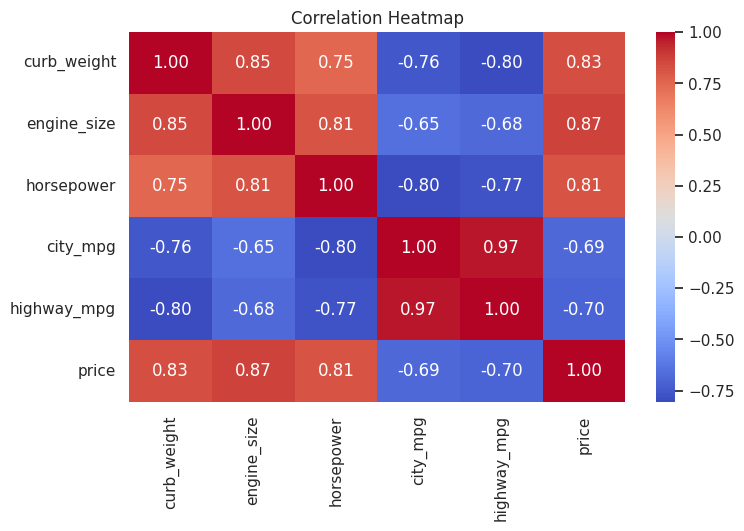

In [55]:
# TODO M2.5: correlation heatmap

sns.heatmap(
    data=df_clean[AUTO_FEATURES].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
)

plt.title('Correlation Heatmap')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Cặp đa cộng tuyến nghiêm trọng (highway_mpg, city_mpg) (engine_size, price)

Đa số các biến đều có mối quan hệ tuyến tính lẫn nhau

Tương quang dương: xe càng năng, động cơ lớn, công suất cao, giá càng cao

Tương quan âm: city_mpg, highway_mpg với các biến còn lại chứ tỏ khả năng tiêu thụ nhiên liệu theo loại xe mạnh



## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

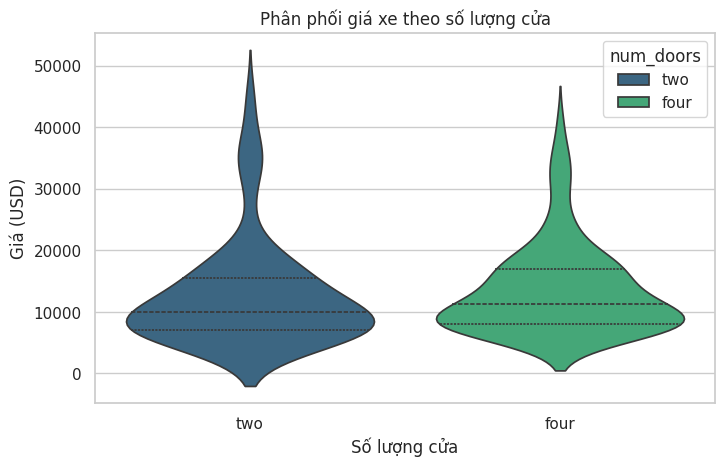

In [58]:
# TODO M2.6: biểu đồ tự chọn

sns.violinplot(
    data=df_clean,
    x='num_doors',
    y='price',
    hue='num_doors',
    palette='viridis',
    inner='quartile',
)

plt.xlabel('Số lượng cửa')
plt.ylabel('Giá (USD)')
plt.title('Phân phối giá xe theo số lượng cửa')
plt.show()

**Nhận xét:**

Biểu đồ violin plot cho thấy rằng xe có 'four' cửa (bốn cửa) thường có phân phối giá rộng hơn và giá trung bình thấp hơn một chút so với xe 'two' cửa (hai cửa). Tuy nhiên, cả hai loại đều có các điểm dữ liệu nằm ngoài (outlier) ở mức giá cao, cho thấy có những mẫu xe cao cấp ở cả hai phân khúc. Xe 2 cửa có vẻ tập trung nhiều ở phân khúc giá cao hơn nhưng số lượng mẫu xe ít hơn so với xe 4 cửa.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

## Tổng hợp của sinh viên

### 3-5 phát hiện chính có dẫn chứng:
1.  **Phân phối giá lệch phải và có ngoại lai:** Biểu đồ histogram/KDE của `price` (M2.1) cho thấy phần lớn xe có giá thấp hơn, và có một số lượng đáng kể xe ở phân khúc giá rất cao tạo thành đuôi dài về bên phải, có thể là các mẫu xe cao cấp hoặc xe sang. Điều này gợi ý rằng dữ liệu giá không tuân theo phân phối chuẩn.
2.  **Sự mất cân bằng về kiểu thân xe:** Countplot của `body_style` (M2.2) chỉ ra rằng 'sedan' và 'hatchback' là hai kiểu thân xe phổ biến nhất, trong khi 'hardtop' và 'convertible' có số lượng rất ít. Điều này có thể ảnh hưởng đến các phân tích hoặc mô hình dự đoán liên quan đến kiểu thân xe.
3.  **Giá cả khác biệt đáng kể giữa các kiểu thân xe:** Biểu đồ boxplot `price` theo `body_style` (M2.3) cho thấy 'hardtop' và 'convertible' có giá trung bình cao nhất, trong khi 'hatchback' có giá thấp nhất. Đặc biệt, 'sedan' mặc dù có giá trung bình nhưng lại có nhiều ngoại lai ở phân khúc giá cao, cho thấy sự đa dạng về cấp độ xe trong kiểu 'sedan'.
4.  **Mối quan hệ tuyến tính mạnh mẽ giữa các đặc trưng kỹ thuật và giá:** Scatterplot giữa `engine_size` và `price` (M2.4), cùng với heatmap tương quan (M2.5), đều chỉ ra mối tương quan dương rất mạnh giữa `engine_size`, `horsepower`, `curb_weight` với `price`. Tức là, xe có động cơ lớn hơn, công suất cao hơn và nặng hơn thường có giá cao hơn.
5.  **Multicollinearity (Đa cộng tuyến) giữa các biến:** Heatmap tương quan (M2.5) cho thấy các cặp biến như `city_mpg` và `highway_mpg` có tương quan gần như hoàn hảo (trên 0.9), cho thấy đa cộng tuyến nghiêm trọng. Tương tự, `engine_size` và `price` cũng có tương quan rất cao, điều này cần được lưu ý khi xây dựng các mô hình hồi quy.

### Ít nhất 2 hạn chế của dataset:
1.  **Thiếu dữ liệu (Missing Values) đáng kể:** Nhiều cột có missing values, đặc biệt là `normalized_losses` thiếu tới 41 giá trị (gần 20% dữ liệu), làm giảm tính hữu dụng của cột này hoặc đòi hỏi phương pháp xử lý missing values phức tạp hơn. Các cột quan trọng khác như `num_doors`, `bore`, `stroke`, `horsepower`, `peak_rpm`, `price` cũng có một vài giá trị thiếu.
2.  **Kích thước tập dữ liệu nhỏ:** Với chỉ 205 dòng dữ liệu, tập dữ liệu này có thể không đủ lớn để huấn luyện các mô hình Machine Learning phức tạp hoặc để đảm bảo tính tổng quát hóa (generalization) của các phát hiện.
3.  **Multicollinearity:** sự tương quan quá cao giữa một số cặp biến có thể gây ra vấn đề cho các mô hình tuyến tính, làm cho việc giải thích ý nghĩa của từng biến trở nên khó khăn.

### Một ví dụ về correlation không đồng nghĩa causation:
*   Mối tương quan dương mạnh giữa `engine_size` và `price` (M2.4) không có nghĩa là việc tăng kích thước động cơ **gây ra** việc tăng giá. `engine_size` có thể chỉ là một chỉ báo (proxy) cho những yếu tố ngầm không phải là nguyên nhân trực tiếp.

### Một câu hỏi nên phân tích tiếp:
* "Các đặc trưng phi số (categorical features) như `make` hoặc `fuel_system` có tác động như thế nào đến giá xe, và liệu có sự tương tác đáng kể nào giữa chúng với các đặc trưng số để giải thích sự biến động của giá không?"